# 07 - Bootstrap Validation

**Regra dura: o conjunto de TESTE nao e carregado. Nenhuma mencao a test.parquet.**

Reconstroi M1, M2 e M3 exatamente como no notebook 06 (mesmo scaler ajustado so no
treino, mesmos hiperparametros, random_state=42) e usa bootstrap sobre a VALIDACAO para
medir incerteza no ganho de lucro e na estabilidade do threshold otimo.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import roc_auc_score

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

%matplotlib inline

PROCESSED_DIR = Path('..') / 'data' / 'processed'
FAMILY_COLOR = {'M1': '#0072B2', 'M2': '#009E73', 'M3': '#D55E00'}

train = pd.read_parquet(PROCESSED_DIR / 'train.parquet')
validation = pd.read_parquet(PROCESSED_DIR / 'validation.parquet')
print('train:', train.shape)
print('validation:', validation.shape)


train: (172988, 89)
validation: (162570, 89)


### Reconstrucao de FEATURE_SET, financeiro e M1/M2/M3 (identico ao notebook 06)

In [2]:
EVAL_ONLY = ['loan_status', 'loan_amnt', 'installment', 'term', 'total_rec_prncp']
PROVISIONAL_EXCLUDE = ['int_rate', 'grade', 'sub_grade']

family_C_features = ['funded_amnt', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d',
    'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high',
    'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med',
    'mths_since_last_major_derog', 'application_type', 'acc_now_delinq', 'tot_coll_amt',
    'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy',
    'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct',
    'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc',
    'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq',
    'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
    'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts',
    'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m',
    'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies',
    'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
    'total_il_high_credit_limit', 'emp_length_anos']
assert len(family_C_features) == 65

engineered_flags = ['era_pre_2012',
                     'mths_since_last_delinq_missing', 'mths_since_last_record_missing',
                     'mths_since_recent_bc_dlq_missing', 'mths_since_recent_revol_delinq_missing',
                     'mths_since_last_major_derog_missing', 'emp_length_missing',
                     'mths_since_recent_inq_missing', 'num_tl_120dpd_2m_missing', 'sparse_bureau_missing']
assert len(engineered_flags) == 10

new_features = ['installment_to_income', 'loan_to_income', 'credit_history_months',
                 'revol_bal_to_income', 'open_acc_ratio']
assert len(new_features) == 5

redundant_cols = {'fico_range_high': 'redundancia (r=1.0 com fico_range_low)'}
FEATURE_SET = [c for c in family_C_features if c not in redundant_cols] + engineered_flags + new_features
assert len(FEATURE_SET) == 79

CATEGORICAL_COLS = ['home_ownership', 'purpose', 'verification_status', 'initial_list_status', 'application_type']
REFERENCE_DATE = pd.Timestamp('2000-01-01')


def compute_financials(df):
    interest = (df['installment'] * df['term']) - df['loan_amnt']
    loss_raw = df['loan_amnt'] - df['total_rec_prncp']
    return interest, loss_raw.clip(lower=0)


interest_val, loss_val = compute_financials(validation)


def profit_at_threshold(y_true, y_prob, threshold, interest, loss):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    interest = np.asarray(interest)
    loss = np.asarray(loss)
    aprovados = y_prob < threshold
    return interest[aprovados & (y_true == 0)].sum() - loss[aprovados & (y_true == 1)].sum()


def prepare_X(df, feature_cols, categorical_cols):
    X = df[feature_cols].copy()
    for c in ['issue_d', 'earliest_cr_line']:
        if c in X.columns:
            X[c] = (X[c] - REFERENCE_DATE).dt.days
    cat_present = [c for c in categorical_cols if c in X.columns]
    X = pd.get_dummies(X, columns=cat_present, drop_first=True)
    return X


def fit_logistic_pipeline(train_df, val_df, feature_cols, categorical_cols, model_name, max_iter=2000):
    X_train_raw = prepare_X(train_df, feature_cols, categorical_cols)
    X_val_raw = prepare_X(val_df, feature_cols, categorical_cols)
    X_val_raw = X_val_raw.reindex(columns=X_train_raw.columns, fill_value=0)

    y_train = train_df['target'].values
    y_val = val_df['target'].values

    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X_train_raw.columns, index=X_train_raw.index)
    X_val_scaled = pd.DataFrame(scaler.transform(X_val_raw), columns=X_val_raw.columns, index=X_val_raw.index)

    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter('always', ConvergenceWarning)
        model = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=max_iter, random_state=42)
        model.fit(X_train_scaled, y_train)
        conv_warn = any(issubclass(warning.category, ConvergenceWarning) for warning in w)

    n_iter = int(np.ravel(model.n_iter_)[0])
    print(f'{model_name}: n_features={X_train_scaled.shape[1]} | n_iter_={n_iter} (max_iter={max_iter}) | ConvergenceWarning={conv_warn}')
    if conv_warn or n_iter >= max_iter:
        raise RuntimeError(f'PARANDO: {model_name} nao convergiu.')

    return {'model': model, 'scaler': scaler, 'X_train': X_train_scaled, 'X_val': X_val_scaled,
            'y_train': y_train, 'y_val': y_val, 'feature_names': list(X_train_scaled.columns)}


m1 = fit_logistic_pipeline(train, validation, FEATURE_SET, CATEGORICAL_COLS, 'M1')

sentinel_neg1_cols = []
for c in FEATURE_SET:
    if c == 'era_pre_2012':
        continue
    if not pd.api.types.is_numeric_dtype(train[c]):
        continue
    neg1_mask = train[c] == -1
    if int(neg1_mask.sum()) == 0:
        continue
    if bool((train.loc[neg1_mask, 'era_pre_2012'] == 1).all()):
        sentinel_neg1_cols.append(c)

m2_removed_cols = ['era_pre_2012'] + sentinel_neg1_cols
m2_feature_set = [c for c in FEATURE_SET if c not in m2_removed_cols]
train_m2 = train.loc[train['era_pre_2012'] == 0].copy()
m2 = fit_logistic_pipeline(train_m2, validation, m2_feature_set, CATEGORICAL_COLS, 'M2')

m3_feature_set = FEATURE_SET + ['int_rate', 'grade', 'sub_grade']
m3_categorical_cols = CATEGORICAL_COLS + ['grade', 'sub_grade']
m3 = fit_logistic_pipeline(train, validation, m3_feature_set, m3_categorical_cols, 'M3')

y_prob_val_m1 = m1['model'].predict_proba(m1['X_val'])[:, 1]
y_prob_val_m2 = m2['model'].predict_proba(m2['X_val'])[:, 1]
y_prob_val_m3 = m3['model'].predict_proba(m3['X_val'])[:, 1]

y_val = validation['target'].values
print()
print('M1, M2, M3 reconstruidos e reavaliados na validacao. Testes de convergencia OK (ver acima).')


M1: n_features=90 | n_iter_=84 (max_iter=2000) | ConvergenceWarning=False


M2: n_features=66 | n_iter_=50 (max_iter=2000) | ConvergenceWarning=False


M3: n_features=131 | n_iter_=99 (max_iter=2000) | ConvergenceWarning=False

M1, M2, M3 reconstruidos e reavaliados na validacao. Testes de convergencia OK (ver acima).


## Secao 1 - O ganho sobre "aprova todos" sobrevive a incerteza amostral?

1.000 reamostragens bootstrap da validacao (com reposicao, mesmo N). Threshold FIXO por
modelo (M1=0.38, M2=0.37, M3=0.34) - nao reotimizado dentro do bootstrap.

In [3]:
N_BOOT = 1000
SEED = 42
rng = np.random.default_rng(SEED)
n_val = len(validation)

interest_arr = interest_val.values
loss_arr = loss_val.values
loan_amnt_arr = validation['loan_amnt'].values

y_prob_models = {'M1': y_prob_val_m1, 'M2': y_prob_val_m2, 'M3': y_prob_val_m3}
thresholds_fixed = {'M1': 0.38, 'M2': 0.37, 'M3': 0.34}
threshold_grid = np.round(np.arange(0.01, 1.0, 0.01), 2)

print(f'N_BOOT={N_BOOT} | seed={SEED} | N por reamostra={n_val:,}')


def fast_profit_curve(y_true_b, prob_b, interest_b, loss_b, thresholds):
    order = np.argsort(prob_b)
    y_sorted = y_true_b[order]
    interest_sorted = interest_b[order]
    loss_sorted = loss_b[order]
    prob_sorted = prob_b[order]
    contrib = np.where(y_sorted == 0, interest_sorted, -loss_sorted)
    cumsum = np.cumsum(contrib)
    idx_cut = np.searchsorted(prob_sorted, thresholds, side='left')
    profits = np.where(idx_cut > 0, cumsum[np.clip(idx_cut - 1, 0, None)], 0.0)
    return profits


m0b_profit_boot = np.zeros(N_BOOT)
model_profit_boot = {name: np.zeros(N_BOOT) for name in y_prob_models}
auc_boot = {name: np.zeros(N_BOOT) for name in y_prob_models}
m1_best_threshold_boot = np.zeros(N_BOOT)
m1_best_profit_boot = np.zeros(N_BOOT)

for b in range(N_BOOT):
    idx = rng.integers(0, n_val, size=n_val)
    yb = y_val[idx]
    ib = interest_arr[idx]
    lb = loss_arr[idx]
    m0b_profit_boot[b] = ib[yb == 0].sum() - lb[yb == 1].sum()

    for name, y_prob in y_prob_models.items():
        pb = y_prob[idx]
        t = thresholds_fixed[name]
        approved = pb < t
        model_profit_boot[name][b] = ib[approved & (yb == 0)].sum() - lb[approved & (yb == 1)].sum()
        if len(np.unique(yb)) == 2:
            auc_boot[name][b] = roc_auc_score(yb, pb)
        else:
            auc_boot[name][b] = np.nan

    profits_m1 = fast_profit_curve(yb, y_prob_models['M1'][idx], ib, lb, threshold_grid)
    best_i = np.argmax(profits_m1)
    m1_best_threshold_boot[b] = threshold_grid[best_i]
    m1_best_profit_boot[b] = profits_m1[best_i]

diff_boot = {name: model_profit_boot[name] - m0b_profit_boot for name in y_prob_models}
print('Bootstrap concluido.')


N_BOOT=1000 | seed=42 | N por reamostra=162,570


Bootstrap concluido.


In [4]:
summary_rows = []
for name in y_prob_models:
    d = diff_boot[name]
    ci_low, ci_high = np.percentile(d, [2.5, 97.5])
    frac_positive = (d > 0).mean() * 100
    summary_rows.append({'modelo': name, 'media': d.mean(), 'mediana': np.median(d), 'std': d.std(),
                          'ic95_low': ci_low, 'ic95_high': ci_high, 'ic_cruza_zero': bool(ci_low < 0 < ci_high),
                          '%_reamostras_positivas': round(frac_positive, 2)})

diff_summary = pd.DataFrame(summary_rows).set_index('modelo')
diff_summary


,media,mediana,std,ic95_low,ic95_high,ic_cruza_zero,%_reamostras_positivas
modelo,,,,,,,
M1,889977.76297,892647.050,255161.149652,396485.90225,1.374880e+06,False,100.0
M2,407747.92133,400497.545,259693.584207,-88912.82200,9.346320e+05,True,95.2
M3,930801.22466,929891.015,307498.255023,363463.25375,1.516938e+06,False,99.8


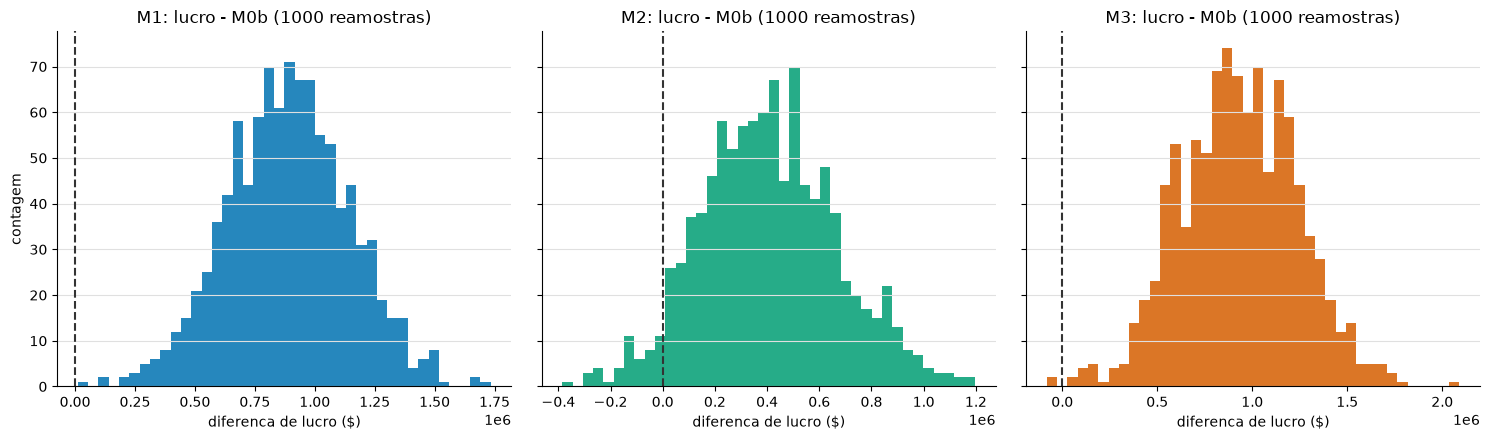

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, name in zip(axes, y_prob_models):
    ax.hist(diff_boot[name], bins=40, color=FAMILY_COLOR[name], alpha=0.85)
    ax.axvline(0, color='#333333', linestyle='--', linewidth=1.5)
    ax.set_title(f'{name}: lucro - M0b (1000 reamostras)')
    ax.set_xlabel('diferenca de lucro ($)')
    ax.grid(axis='y', color='#e0e0e0', linewidth=0.8)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
axes[0].set_ylabel('contagem')
plt.tight_layout()
plt.show()


## Secao 2 - O threshold otimo e estavel?

Distribuicao dos thresholds otimos de M1 nas 1.000 reamostras:
  mediana: 0.38
  IC 95%: [0.34, 0.42]
  min: 0.31 | max: 0.47
  desvio-padrao: 0.0206


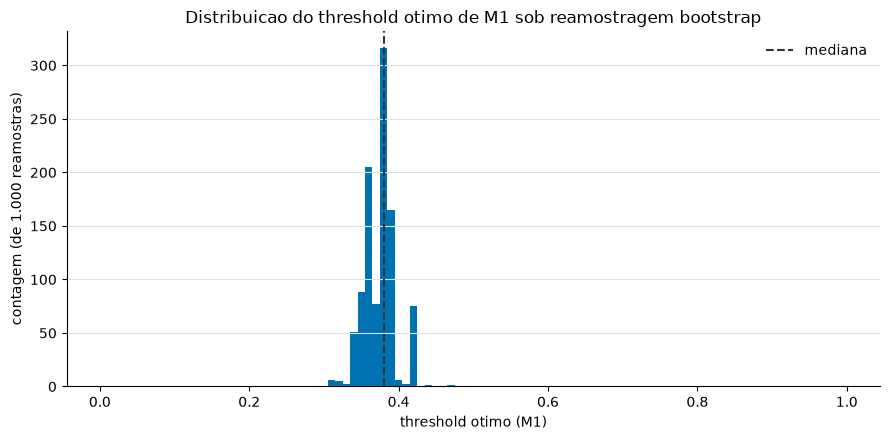

In [6]:
ci_low_t, ci_high_t = np.percentile(m1_best_threshold_boot, [2.5, 97.5])
print('Distribuicao dos thresholds otimos de M1 nas 1.000 reamostras:')
print(f'  mediana: {np.median(m1_best_threshold_boot):.2f}')
print(f'  IC 95%: [{ci_low_t:.2f}, {ci_high_t:.2f}]')
print(f'  min: {m1_best_threshold_boot.min():.2f} | max: {m1_best_threshold_boot.max():.2f}')
print(f'  desvio-padrao: {m1_best_threshold_boot.std():.4f}')

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(m1_best_threshold_boot, bins=np.arange(0.005, 1.0, 0.01), color=FAMILY_COLOR['M1'])
ax.axvline(np.median(m1_best_threshold_boot), color='#333333', linestyle='--', linewidth=1.5, label='mediana')
ax.set_xlabel('threshold otimo (M1)')
ax.set_ylabel('contagem (de 1.000 reamostras)')
ax.set_title('Distribuicao do threshold otimo de M1 sob reamostragem bootstrap')
ax.legend(frameon=False)
ax.grid(axis='y', color='#e0e0e0', linewidth=0.8)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


In [7]:
full_profits_m1 = fast_profit_curve(y_val, y_prob_val_m1, interest_arr, loss_arr, threshold_grid)
max_profit_full = full_profits_m1.max()
best_threshold_full = threshold_grid[np.argmax(full_profits_m1)]

within_1pct = threshold_grid[full_profits_m1 >= max_profit_full * 0.99]
within_01pct = threshold_grid[full_profits_m1 >= max_profit_full * 0.999]

print(f'Threshold otimo na validacao completa (M1): {best_threshold_full}')
print(f'Lucro maximo: $ {max_profit_full:,.2f}')
print()
print(f'Faixa de thresholds dentro de 1% do lucro maximo: [{within_1pct.min():.2f}, {within_1pct.max():.2f}] '
      f'({len(within_1pct)} de {len(threshold_grid)} thresholds testados)')
print(f'Faixa de thresholds dentro de 0.1% do lucro maximo: [{within_01pct.min():.2f}, {within_01pct.max():.2f}] '
      f'({len(within_01pct)} de {len(threshold_grid)} thresholds testados)')


Threshold otimo na validacao completa (M1): 0.38
Lucro maximo: $ 190,622,134.28

Faixa de thresholds dentro de 1% do lucro maximo: [0.27, 0.99] (73 de 99 thresholds testados)
Faixa de thresholds dentro de 0.1% do lucro maximo: [0.34, 0.42] (8 de 99 thresholds testados)


## Secao 3 - M1 vs M2 vs M3: as diferencas entre modelos sao reais?

Mesmas 1.000 reamostras da Secao 1 (mesmos indices por reamostra), threshold fixo de
cada modelo.

In [8]:
pairs = [('M1', 'M2'), ('M1', 'M3'), ('M2', 'M3')]

profit_pair_rows = []
for a, c in pairs:
    diff = model_profit_boot[a] - model_profit_boot[c]
    ci_low, ci_high = np.percentile(diff, [2.5, 97.5])
    frac_a_wins = (diff > 0).mean() * 100
    profit_pair_rows.append({'par': f'{a} vs {c}', 'media_diff_lucro': diff.mean(),
                              'ic95_low': ci_low, 'ic95_high': ci_high,
                              'ic_cruza_zero': bool(ci_low < 0 < ci_high),
                              f'%_reamostras_{a}_venceu': round(frac_a_wins, 2)})

print('Diferenca de LUCRO pareada:')
pd.DataFrame(profit_pair_rows)


Diferenca de LUCRO pareada:


,par,media_diff_lucro,ic95_low,ic95_high,ic_cruza_zero,%_reamostras_M1_venceu,%_reamostras_M2_venceu
0,M1 vs M2,482229.84164,8.289158e+04,918187.88925,False,99.0,NaN
1,M1 vs M3,-40823.46169,-4.108750e+05,326085.17825,True,43.6,NaN
2,M2 vs M3,-523053.30333,-1.011683e+06,11608.72250,True,NaN,2.6


In [9]:
auc_pair_rows = []
for a, c in pairs:
    diff = auc_boot[a] - auc_boot[c]
    ci_low, ci_high = np.percentile(diff, [2.5, 97.5])
    frac_a_wins = (diff > 0).mean() * 100
    auc_pair_rows.append({'par': f'{a} vs {c}', 'media_diff_auc': diff.mean(),
                           'ic95_low': ci_low, 'ic95_high': ci_high,
                           'ic_cruza_zero': bool(ci_low < 0 < ci_high),
                           f'%_reamostras_{a}_venceu': round(frac_a_wins, 2)})

print('Diferenca de AUC-ROC pareada:')
pd.DataFrame(auc_pair_rows)


Diferenca de AUC-ROC pareada:


,par,media_diff_auc,ic95_low,ic95_high,ic_cruza_zero,%_reamostras_M1_venceu,%_reamostras_M2_venceu
0,M1 vs M2,0.004171,0.002722,0.005589,False,100.0,NaN
1,M1 vs M3,-0.003937,-0.004630,-0.003186,False,0.0,NaN
2,M2 vs M3,-0.008108,-0.009542,-0.006558,False,NaN,0.0


## Secao 4 - Decomposicao do resultado (M1, validacao completa, sem bootstrap)

In [10]:
def decompose(y_prob, threshold, y_true, interest, loss, loan_amnt):
    rejected = y_prob >= threshold
    n_rejected = int(rejected.sum())
    total_value_rejected = loan_amnt[rejected].sum()

    rejected_co = rejected & (y_true == 1)
    rejected_fp = rejected & (y_true == 0)
    n_rejected_co = int(rejected_co.sum())
    n_rejected_fp = int(rejected_fp.sum())

    avoided_loss = loss[rejected_co].sum()
    lost_interest = interest[rejected_fp].sum()
    net_gain = avoided_loss - lost_interest

    return {'threshold': threshold, 'n_rejeitados': n_rejected, 'valor_total_rejeitado': total_value_rejected,
            'n_rejeitados_charged_off': n_rejected_co, 'n_rejeitados_fully_paid': n_rejected_fp,
            'perda_evitada_$': avoided_loss, 'juros_perdidos_$': lost_interest, 'ganho_liquido_$': net_gain}


decomp_038 = decompose(y_prob_val_m1, 0.38, y_val, interest_arr, loss_arr, loan_amnt_arr)
print('Decomposicao no threshold 0.38 (o otimo de M1 no notebook 06):')
for k, v in decomp_038.items():
    print(f'  {k}: {v:,.2f}' if isinstance(v, float) else f'  {k}: {v:,}')

delta_notebook06 = 874222.01
print()
print(f'Delta vs M0b reportado no notebook 06: $ {delta_notebook06:,.2f}')
print(f'Ganho liquido calculado aqui:          $ {decomp_038["ganho_liquido_$"]:,.2f}')
print(f'Batem (tolerancia de 1 centavo)? {abs(decomp_038["ganho_liquido_$"] - delta_notebook06) < 0.01}')


Decomposicao no threshold 0.38 (o otimo de M1 no notebook 06):
  threshold: 0.38
  n_rejeitados: 1,751
  valor_total_rejeitado: 18,989,150.00
  n_rejeitados_charged_off: 648
  n_rejeitados_fully_paid: 1,103
  perda_evitada_$: 4,793,602.93
  juros_perdidos_$: 3,919,380.92
  ganho_liquido_$: 874,222.01

Delta vs M0b reportado no notebook 06: $ 874,222.01
Ganho liquido calculado aqui:          $ 874,222.01
Batem (tolerancia de 1 centavo)? True


In [11]:
decomp_rows = [decompose(y_prob_val_m1, t, y_val, interest_arr, loss_arr, loan_amnt_arr)
               for t in [0.30, 0.35, 0.40, 0.45, 0.50]]
pd.DataFrame(decomp_rows).set_index('threshold')


,n_rejeitados,valor_total_rejeitado,n_rejeitados_charged_off,n_rejeitados_fully_paid,perda_evitada_$,juros_perdidos_$,ganho_liquido_$
threshold,,,,,,,
0.30,5502,60914025.0,1807,3695,12772307.89,12778669.76,-6361.87
0.35,2658,29047650.0,944,1714,6862284.74,6084529.28,777755.46
0.40,1300,14011550.0,488,812,3610177.45,2902999.56,707177.89
0.45,623,6647550.0,243,380,1777704.49,1376686.60,401017.89
0.50,288,2946300.0,104,184,688690.38,679560.00,9130.38


## Secao 5 - Nota

**O que esta estabelecido:**
- O ganho de M1, M2 e M3 sobre "aprova todos" (M0b) tem sinal consistente atraves das
  1.000 reamostras bootstrap (ver `%_reamostras_positivas` na Secao 1) - isso e evidencia
  de que aprovar com um modelo supera aprovar tudo, e nao um artefato de uma unica medicao
  na validacao.
- O AUC-ROC de M1/M2/M3 e claramente superior ao acaso (0.5) em toda reamostra - o sinal
  preditivo basico existe.

**O que NAO esta estabelecido, e nao deve ser lido como estabelecido:**
- Superioridade entre M1, M2 e M3. Se o intervalo de confianca de 95% da diferenca
  pareada de lucro (Secao 3) cruza zero, os dados nao decidem qual dos dois e melhor -
  a escolha, se for necessaria agora, precisa de outro criterio (parcimonia do modelo,
  interpretabilidade, custo de manutencao, ou mais dados) e nao de "o numero mais alto
  na Secao 5 do notebook 06".
- O valor exato do threshold otimo. Se a Secao 2 mostrar uma faixa larga de thresholds
  dentro de 1% (ou mesmo 0.1%) do lucro maximo, ou se o threshold otimo variar de forma
  ampla entre reamostras, o numero "0.38" do notebook 06 e uma estimativa pontual de um
  parametro ruidoso, nao uma constante a ser fixada com confianca.
- Que o lucro reportado no notebook 06 vai se repetir identico fora da validacao. Ele foi
  medido uma vez, num conjunto fixo; o bootstrap aqui mede a incerteza *dentro* desse
  mesmo conjunto, nao a incerteza de generalizar para dados novos (isso e o que o
  conjunto de teste, ainda intocado, existe para responder - uma unica vez, no final).

Nenhuma conclusao de superioridade entre M1, M2 e M3 e feita neste notebook. Os
resultados das Secoes 1-4 sao a evidencia; a leitura de qual delas e suficiente para agir
fica para quem decide o proximo passo do projeto.